# TASK- 4 Email Spam Detection with Machine learning

In [1]:
import pandas as pd
import numpy as np
import re                      
import matplotlib.pyplot as plt
import seaborn as sns

# NLP libraries
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report



### Load Data and Check Class distribution

In [2]:
# For special character we used encoding = "latin-1"
df = pd.read_csv('spam.csv', encoding='latin-1')
# for first 2 column
df = df[['v1', 'v2']]

# give the columns meaningful names
df.columns = ['label', 'message']

print(df.shape)
df.head()

(5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


### Check count of ham and spam messages 

label
ham     4825
spam     747
Name: count, dtype: int64
label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


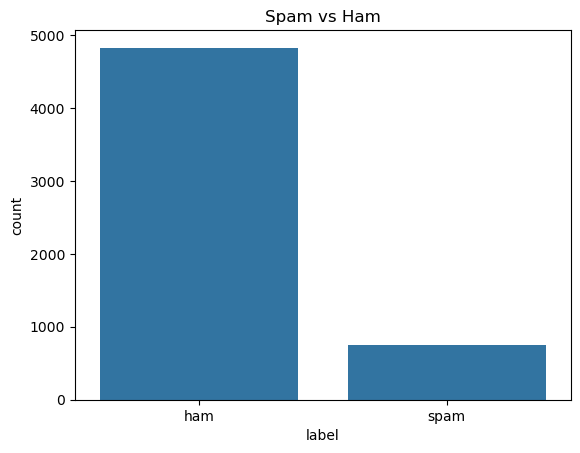

In [3]:
# count of each class
print(df['label'].value_counts())

# percentage of each class
print(df['label'].value_counts(normalize=True) * 100)

# a simple bar chart
sns.countplot(x='label', data=df)
plt.title('Spam vs Ham')
plt.show()

In [4]:
# check for missing values and duplicates
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()

label      0
message    0
dtype: int64
Duplicates: 403


In [5]:
# converting the lables to numbers because ML model need Numbers
# ham = 0, spam = 1
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})
df.head()

,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


### Text Preprocessing

In [6]:
stop_words = set(stopwords.words('english'))

# stemmer object
stemmer = PorterStemmer()

def clean_text(text):
    # 1. convert to lowercase
    text = text.lower()

    # 2. remove everything except letters (removes punctuation and numbers)
    text = re.sub('[^a-z]', ' ', text)

    # 3. split the sentence into a list of words
    words = text.split()

    # 4. remove stopwords and apply stemming
    cleaned_words = []
    for word in words:
        if word not in stop_words:
            cleaned_words.append(stemmer.stem(word))

    # 5. join the words back into one sentence
    return ' '.join(cleaned_words)

In [7]:
# testing in one of examples
print(clean_text("WINNER!! You have won a FREE prize, call 09061 now!!!"))

winner free prize call


In [8]:
# applying to whole data set 
df['clean_message'] = df['message'].apply(clean_text)
df[['message', 'clean_message']].head()

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...
3,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


### Feature Extraction

In [9]:
X = df['clean_message']   
y = df['label_num']       

# 80% for training, 20% for testing
# stratify=y keeps the same spam/ham ratio in both parts
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training size:", X_train.shape[0])
print("Testing size:", X_test.shape[0])

Training size: 4135
Testing size: 1034


In [10]:
# create the TF-IDF converter (keep the 3000 most important words)
tfidf = TfidfVectorizer(max_features=3000)

# learn the vocabulary from TRAINING data and convert it
X_train_tfidf = tfidf.fit_transform(X_train)

# for test data, only convert (don't learn again)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)

(4135, 3000)


### Training The Models

In [11]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)     # training happens here

nb_pred = nb_model.predict(X_test_tfidf) # predict on unseen data

In [12]:
lr_model = LogisticRegression()
lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)

 ### Evaluation

In [13]:
def show_results(model_name, y_true, y_pred):
    print("=====", model_name, "=====")
    print("Accuracy :", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred), 4))
    print("Recall   :", round(recall_score(y_true, y_pred), 4))
    print("F1 Score :", round(f1_score(y_true, y_pred), 4))
    print()
    print(classification_report(y_true, y_pred, target_names=['Ham', 'Spam']))

show_results("Naive Bayes", y_test, nb_pred)
show_results("Logistic Regression", y_test, lr_pred)

===== Naive Bayes =====
Accuracy : 0.972
Precision: 0.9811
Recall   : 0.7939
F1 Score : 0.8776

              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       903
        Spam       0.98      0.79      0.88       131

    accuracy                           0.97      1034
   macro avg       0.98      0.90      0.93      1034
weighted avg       0.97      0.97      0.97      1034

===== Logistic Regression =====
Accuracy : 0.9652
Precision: 1.0
Recall   : 0.7252
F1 Score : 0.8407

              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       903
        Spam       1.00      0.73      0.84       131

    accuracy                           0.97      1034
   macro avg       0.98      0.86      0.91      1034
weighted avg       0.97      0.97      0.96      1034



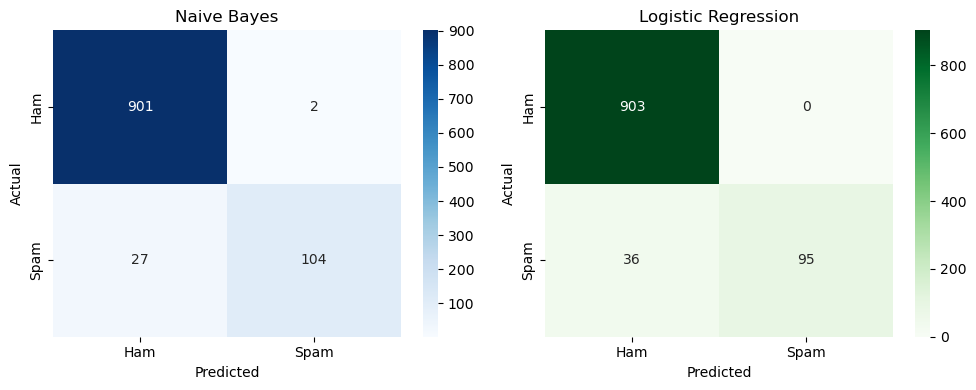

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Naive Bayes
cm1 = confusion_matrix(y_test, nb_pred)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
axes[0].set_title('Naive Bayes')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Logistic Regression
cm2 = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
axes[1].set_title('Logistic Regression')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [15]:
results = pd.DataFrame({
    'Model': ['Naive Bayes', 'Logistic Regression'],
    'Accuracy': [accuracy_score(y_test, nb_pred), accuracy_score(y_test, lr_pred)],
    'Precision': [precision_score(y_test, nb_pred), precision_score(y_test, lr_pred)],
    'Recall': [recall_score(y_test, nb_pred), recall_score(y_test, lr_pred)],
    'F1': [f1_score(y_test, nb_pred), f1_score(y_test, lr_pred)]
})
results

,Model,Accuracy,Precision,Recall,F1
0,Naive Bayes,0.971954,0.981132,0.793893,0.877637
1,Logistic Regression,0.965184,1.000000,0.725191,0.840708


### Discussion (markdown cell)

Why is recall important for spam detection?

Recall tells us how much of the actual spam our model manages to catch. A low recall means many spam messages slip through into the inbox (false negatives). These can be phishing links, scams, or malware, and a single missed message can cause real harm, such as someone losing money or having their data stolen.

Recall also matters because spam is the minority class (~13%). A model can look 87% accurate while catching almost no spam, so accuracy alone is misleading and recall shows how well we detect the class we care about.

However, recall should not be looked at alone. If we mark everything as spam, recall is 100% but important emails get lost (low precision). So we use the F1-score to balance both. In practice, many systems prefer slightly higher precision, since losing an important email is also costly, but missing dangerous spam is the main failure we try to minimise.

### Bonus Cloud

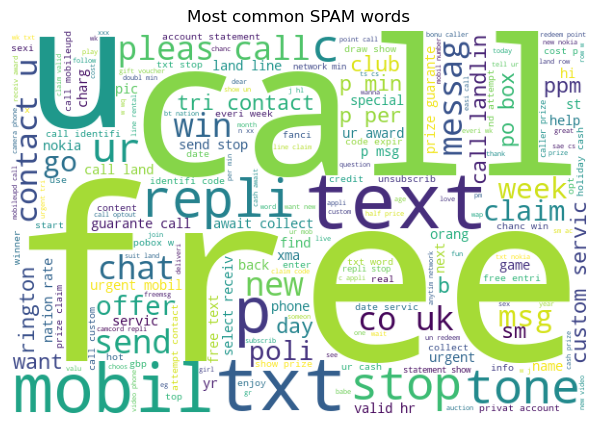

In [16]:
from wordcloud import WordCloud

# join all spam messages into one big string, same for ham
spam_words = ' '.join(df[df['label'] == 'spam']['clean_message'])
ham_words = ' '.join(df[df['label'] == 'ham']['clean_message'])

# Spam wordcloud
spam_cloud = WordCloud(width=600, height=400, background_color='white').generate(spam_words)
plt.figure(figsize=(8, 5))
plt.imshow(spam_cloud)
plt.axis('off')
plt.title('Most common SPAM words')
plt.show()



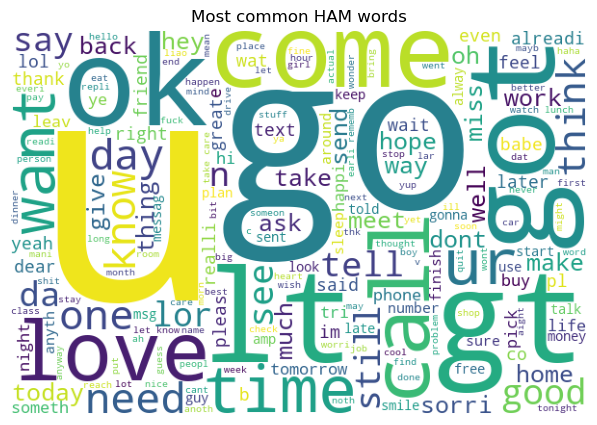

In [17]:
# Ham wordcloud
ham_cloud = WordCloud(width=600, height=400, background_color='white').generate(ham_words)
plt.figure(figsize=(8, 5))
plt.imshow(ham_cloud)
plt.axis('off')
plt.title('Most common HAM words')
plt.show()